                                     Netflix Business Case Study
**Business Problem : **
Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries.

What type of content is available in different countries?

We analyze the dataset using:

•  Total content per country

•  Movies vs TV Shows per country

•  Top genres per country


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your file name
df = pd.read_csv('/content/sample_data/netflix.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
# Clean Country Column
# Remove rows with missing country
df = df.dropna(subset=['country'])

# Split multiple countries
df['country'] = df['country'].str.split(',')

# Create separate row for each country
df = df.explode('country')

# Remove extra spaces
df['country'] = df['country'].str.strip()

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...


In [ ]:
# Total Content by Country
country_count = df['country'].value_counts()

# Top 10 countries
top_10_countries = country_count.head(10)

print(top_10_countries)

country
United States     6780
India             2804
United Kingdom    1783
France             916
Canada             877
Japan              733
South Korea        632
Spain              591
Germany            511
Mexico             409
Name: count, dtype: int64


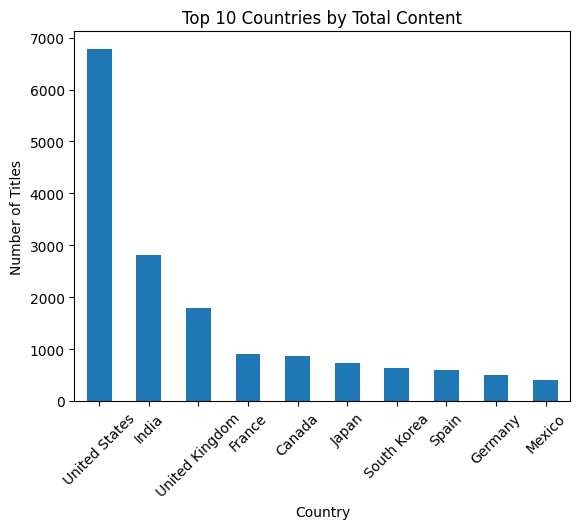

In [ ]:
# Plot Top 10 Countries
plt.figure()
top_10_countries.plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.title("Top 10 Countries by Total Content")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Movies vs TV Shows by Country
country_type = df.groupby(['country','type']).size().unstack(fill_value=0)

# Top 10 countries only
top_10_country_type = country_type.loc[top_10_countries.index]

print(top_10_country_type)

type            Movie  TV Show
country                       
United States    5019     1761
India            2606      198
United Kingdom   1069      714
France            726      190
Canada            633      244
Japan             294      439
South Korea       150      482
Spain             416      175
Germany           402      109
Mexico            245      164


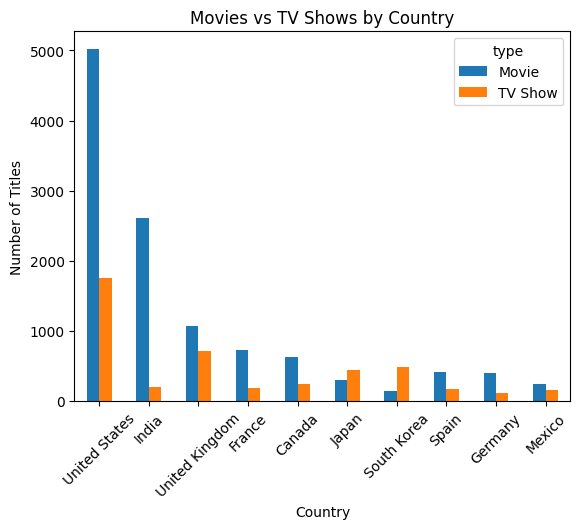

In [ ]:
# Plot Movies vs TV Shows
top_10_country_type.plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.title("Movies vs TV Shows by Country")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Genre Distribution by Country
# Split genres
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')
df['listed_in'] = df['listed_in'].str.strip()

# Count genre by country
genre_country = df.groupby(['country','listed_in']).size().reset_index(name='count')

# Find top genre per country
top_genre_country = genre_country.sort_values(['country','count'], ascending=False)

print(top_genre_country.head(20))

           country                 listed_in  count
1413      Zimbabwe      International Movies      3
1412      Zimbabwe             Documentaries      2
1411      Zimbabwe                  Comedies      1
1414      Zimbabwe           Romantic Movies      1
1406  West Germany      International Movies      2
1401  West Germany  Children & Family Movies      1
1402  West Germany            Classic Movies      1
1403  West Germany                  Comedies      1
1404  West Germany             Documentaries      1
1405  West Germany             Horror Movies      1
1407  West Germany    International TV Shows      1
1408  West Germany               TV Comedies      1
1409  West Germany                 TV Dramas      1
1410  West Germany                 Thrillers      1
1397       Vietnam      International Movies      7
1395       Vietnam                    Dramas      4
1392       Vietnam        Action & Adventure      2
1393       Vietnam                  Comedies      2
1394       V

# How has the number of movies released per year changed over the last 20-30 years?

In [ ]:
# Filter Only Movies
movies = df[df['type'] == 'Movie']
# Count Movies per Release Year
movies_per_year = movies.groupby('release_year').size().reset_index(name='count')
# Filter Last 30 Years (Example: 1995–2025)
recent_movies = movies_per_year[movies_per_year['release_year'] >= 1995]
recent_movies

,release_year,count
46,1995,51
47,1996,41
48,1997,78
49,1998,87
50,1999,85
51,2000,109
52,2001,106
53,2002,148
54,2003,160
55,2004,175


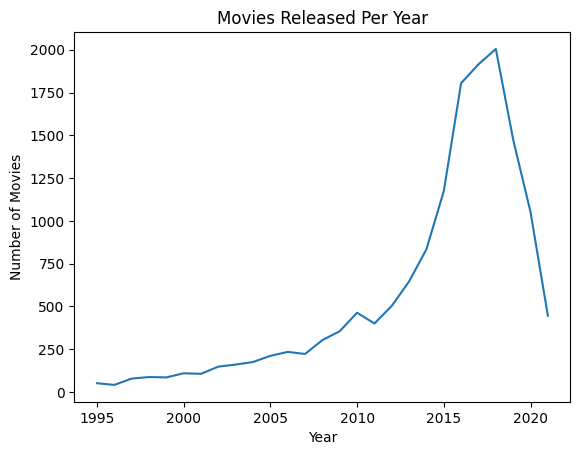

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recent_movies['release_year'], recent_movies['count'])
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")
plt.show()

Comparison of tv shows vs. movies.

In [ ]:
# Comparison of tv shows vs. movies.
df['type'].value_counts()

,count
type,
Movie,16025
TV Show,6017


In [ ]:
# Growth Trend Over Years
df.groupby(['release_year','type']).size().unstack()

type,Movie,TV Show
release_year,,
1942,4.0,NaN
1943,4.0,NaN
1944,8.0,NaN
1945,6.0,1.0
1946,2.0,1.0
...,...,...
2017,1915.0,621.0
2018,2005.0,860.0
2019,1475.0,921.0


In [ ]:
# Country-Wise Comparison
df.groupby(['country','type']).size()

country       type   
              Movie      13
              TV Show     2
Afghanistan   Movie       2
Albania       Movie       2
Algeria       Movie       8
                         ..
Venezuela     Movie       8
Vietnam       Movie      20
West Germany  Movie       8
              TV Show     3
Zimbabwe      Movie       7
Length: 184, dtype: int64

In [ ]:
df.groupby(['country','type']) \
  .size() \
  .reset_index(name='count') \
  .sort_values(by='count', ascending=False)

,country,type,count
174,United States,Movie,5019
67,India,Movie,2606
175,United States,TV Show,1761
172,United Kingdom,Movie,1069
52,France,Movie,726
...,...,...,...
84,Kazakhstan,Movie,1
114,Nicaragua,Movie,1
145,Somalia,Movie,1
167,Uganda,Movie,1


What is the best time to launch a TV show?

In [ ]:
# Filter Only TV Shows
tv = df[df['type'] == 'TV Show']
#tv
tv.shape[0]

6017

In [ ]:
# Extract Month & Year

# Remove missing values first
tv = tv.dropna(subset=['date_added'])

# Remove extra spaces
tv['date_added'] = tv['date_added'].str.strip()

# Convert safely
tv['date_added'] = pd.to_datetime(tv['date_added'], errors='coerce')

# Extract month and year
tv['month_added'] = tv['date_added'].dt.month
tv['year_added'] = tv['date_added'].dt.year

tv.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",9,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",9,2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",9,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...,9,2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,Romantic TV Shows,In a city of coaching centers known to train I...,9,2021


In [ ]:
# Count TV Shows by Month
monthly_launch = tv.groupby('month_added').size().reset_index(name='count')

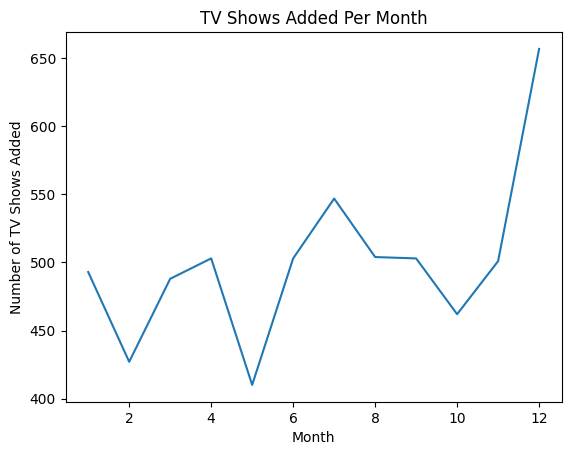

In [ ]:
# Plot Monthly Trend
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_launch['month_added'], monthly_launch['count'])
plt.xlabel("Month")
plt.ylabel("Number of TV Shows Added")
plt.title("TV Shows Added Per Month")
plt.show()

Analysis of actors/directors of different types of shows/movies.

In [ ]:
# Data Preparation
import pandas as pd

# Drop missing values
df = df.dropna(subset=['cast', 'director'])

# Split cast column
df['cast'] = df['cast'].str.split(',')
df = df.explode('cast')
df['cast'] = df['cast'].str.strip()

# Split director column
df['director'] = df['director'].str.split(',')
df = df.explode('director')
df['director'] = df['director'].str.strip()

In [ ]:
# Actor Analysis: Most Frequent Actors in Movies vs TV Shows
actor_type = df.groupby(['cast','type']).size().reset_index(name='count')
actor_type

,cast,type,count
0,"""Riley"" Lakdhar Dridi",Movie,3
1,'Najite Dede,Movie,3
2,2Mex,Movie,2
3,50 Cent,Movie,8
4,A. Murat Özgen,Movie,2
...,...,...,...
25938,Şevket Çoruh,Movie,2
25939,Şinasi Yurtsever,Movie,9
25940,Şükran Ovalı,Movie,2
25941,Şükrü Özyıldız,Movie,2


In [ ]:
# Director Analysis: Directors by Type
director_type = df.groupby(['director','type']).size().reset_index(name='count')
director_type

,director,type,count
0,A. L. Vijay,Movie,42
1,A. Raajdheep,Movie,10
2,A. Salaam,Movie,30
3,A.R. Murugadoss,Movie,12
4,Aadish Keluskar,Movie,12
...,...,...,...
4355,Éric Warin,Movie,36
4356,Ísold Uggadóttir,Movie,27
4357,Óskar Thór Axelsson,Movie,20
4358,Ömer Faruk Sorak,Movie,84


In [ ]:
# Country-Wise Actor/Director Trend
df.groupby(['country','cast','type']).size()

country   cast                          type 
          Ala' Hanani                   Movie    2
          Ameer Khlawe                  Movie    2
          Angie Saba                    Movie    2
          Areen Omari                   Movie    3
          Aude-Laurence Clermont Biver  Movie    2
                                                ..
Zimbabwe  Kudzai Sevenzo                Movie    3
          Michael Kudakwashe            Movie    3
          Tendai Nguni                  Movie    3
          Tendaiishe Chitima            Movie    3
          Zihlo                         Movie    3
Length: 39401, dtype: int64

Does Netflix has more focus on TV Shows than movies in recent years

In [ ]:
# Compare Movies vs TV Shows Added Per Year
import pandas as pd

# Remove null values
df = df.dropna(subset=['date_added'])

# Clean spaces
df['date_added'] = df['date_added'].str.strip()

# Convert safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop invalid conversions
df = df.dropna(subset=['date_added'])

# Extract year
df['year_added'] = df['date_added'].dt.year

# Group
year_type = df.groupby(['year_added','type']).size().unstack(fill_value=0)

year_type

type,Movie,TV Show
year_added,,
2008,18,0
2009,30,0
2010,20,0
2011,438,0
2012,36,0
2013,75,30
2014,330,0
2015,1062,63
2016,4621,150


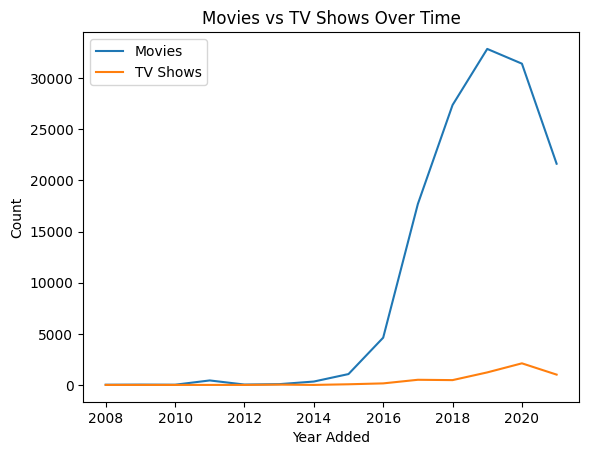

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.plot(year_type.index, year_type['Movie'], label='Movies')
plt.plot(year_type.index, year_type['TV Show'], label='TV Shows')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.title('Movies vs TV Shows Over Time')
plt.legend()
plt.show()

Understanding what content is available in different countries

In [ ]:
# Clean the Country Column
# Remove missing country values
df = df.dropna(subset=['country'])

# Split multiple countries
df['country'] = df['country'].str.split(',')

# Create separate row for each country
df = df.explode('country')

df['country'] = df['country'].str.strip()

In [ ]:
# Total Content by Country
country_count = df['country'].value_counts()
country_count

,count
country,
United States,45773
India,21762
United Kingdom,9010
France,6816
Canada,5793
...,...
Vatican City,3
Sri Lanka,2
Afghanistan,2


In [ ]:
# Movies vs TV Shows by Country
df.groupby(['country','type']).size()

,,0
country,type,
,Movie,95
Afghanistan,Movie,2
Albania,Movie,8
Algeria,Movie,77
Angola,Movie,32
...,...,...
Vatican City,Movie,3
Venezuela,Movie,23
Vietnam,Movie,134


In [ ]:
# Genre Distribution by Country
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')
df['listed_in'] = df['listed_in'].str.strip()
result = df.groupby(['country','listed_in']) \
           .size() \
           .reset_index(name='count') \
           .sort_values(by='count', ascending=False)

result.head(20)

,country,listed_in,count
976,United States,Comedies,8253
981,United States,Dramas,8129
367,India,International Movies,7012
363,India,Dramas,5542
973,United States,Children & Family Movies,4761
970,United States,Action & Adventure,4492
984,United States,Independent Movies,3895
1009,United States,Thrillers,2698
359,India,Comedies,2675
993,United States,Romantic Movies,2230


In [ ]:
# Recent Growth by Country
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

df.groupby(['country','year_added']).size()

country       year_added
              2019          27
              2020          26
              2021          42
Afghanistan   2017           2
Albania       2018           8
                            ..
Vietnam       2020           3
              2021          68
West Germany  2019          30
              2020          30
Zimbabwe      2020          36
Length: 414, dtype: int64